In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles, make_classification, make_gaussian_quantiles
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
from sklearn.covariance import EmpiricalCovariance
import itertools

In [ ]:
# Custom metric for Mahalanobis
def mahalanobis_distance(X):
    cov = EmpiricalCovariance().fit(X)
    inv_cov = cov.precision_
    return lambda u, v: mahalanobis(u, v, inv_cov)

In [ ]:
# Dataset options
dataset_options = {
    'blobs': lambda: make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42),
    'moons': lambda: make_moons(n_samples=500, noise=0.05, random_state=42),
    'circles': lambda: make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42),
    'classification': lambda: make_classification(n_samples=500, n_features=2, n_informative=2, n_clusters_per_class=1, random_state=42),
    'gaussian_quantiles': lambda: make_gaussian_quantiles(n_samples=500, n_features=2, random_state=42)
}

In [ ]:
# Choose dataset
dataset_name = 'blobs'  # Change this to use a different dataset: 'moons', 'circles', 'classification', 'gaussian_quantiles'
data, labels_true = dataset_options[dataset_name]()

# Standardize dataset
data = StandardScaler().fit_transform(data)

In [ ]:
# Hyperparameter grid
eps_values = np.linspace(0.1, 1.0, 10)
min_samples_values = range(3, 10)
metrics = ['euclidean', 'manhattan', mahalanobis_distance(data)]  # Adding Mahalanobis

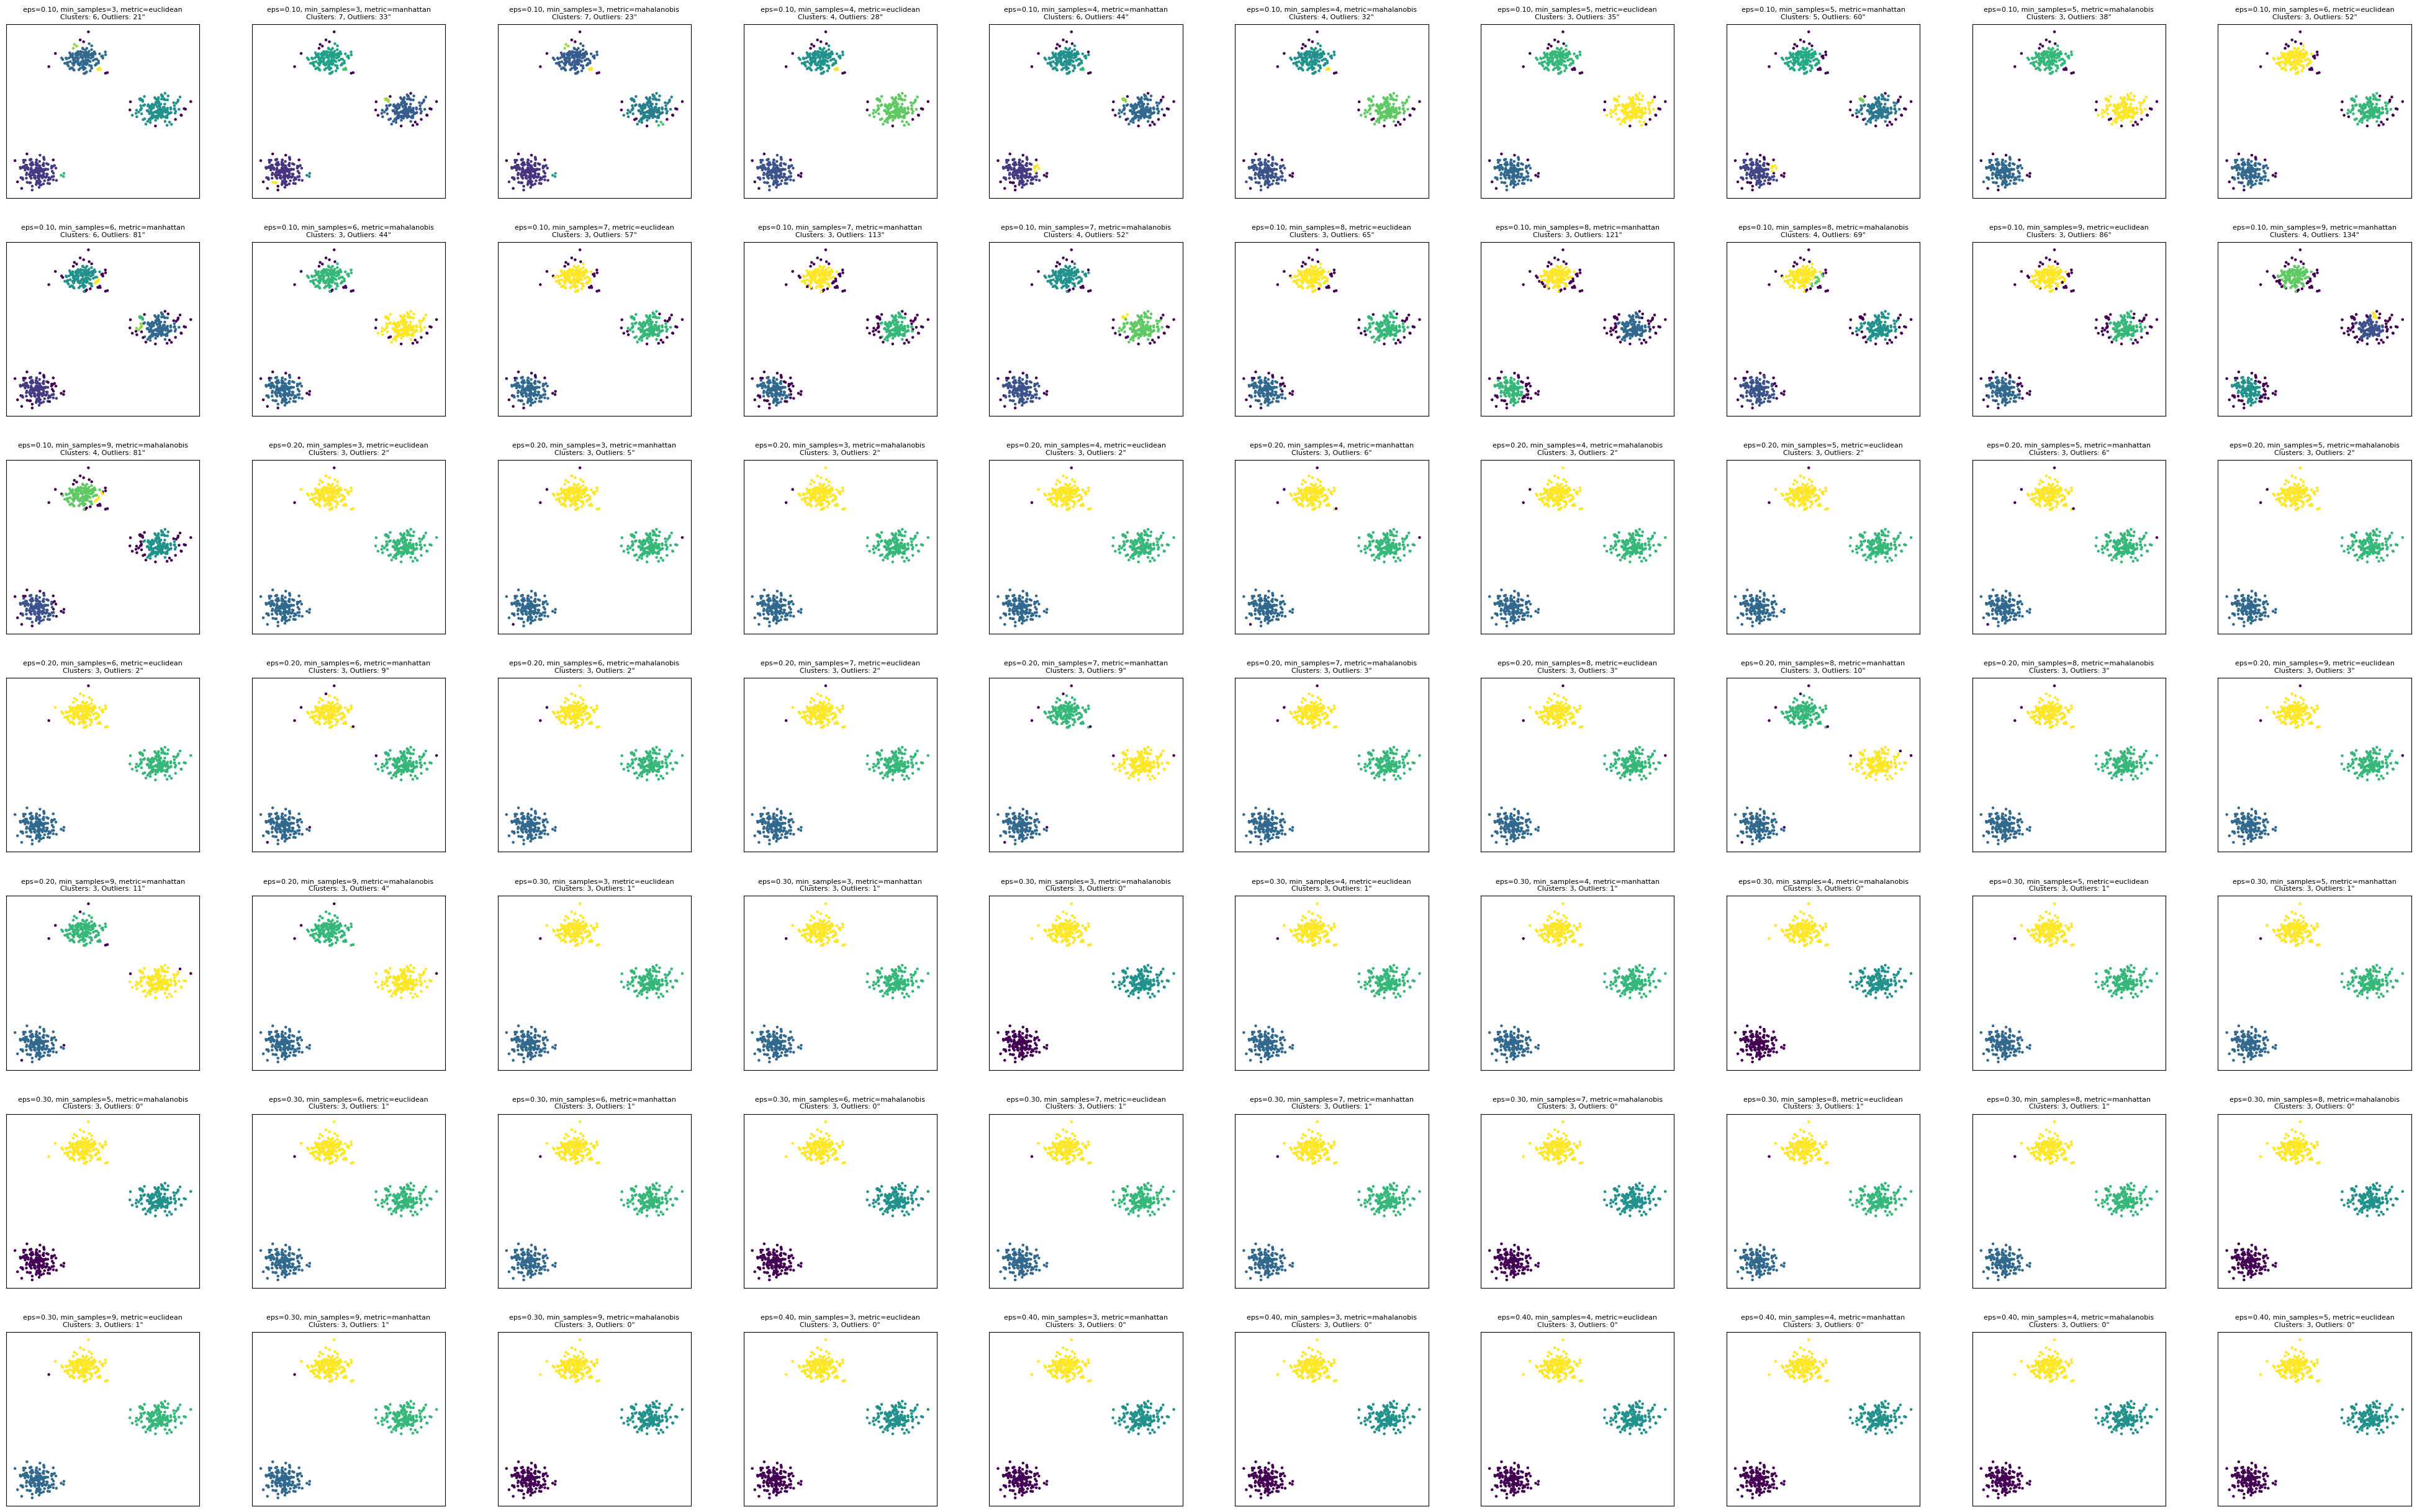

     eps  min_samples       metric  silhouette_score
0    0.1            3    euclidean          0.843896
1    0.1            3    manhattan          0.843896
2    0.1            3  mahalanobis          0.843896
3    0.1            4    euclidean          0.843896
4    0.1            4    manhattan          0.843896
..   ...          ...          ...               ...
205  1.0            8    manhattan          0.843896
206  1.0            8  mahalanobis          0.843896
207  1.0            9    euclidean          0.843896
208  1.0            9    manhattan          0.843896
209  1.0            9  mahalanobis          0.843896

[210 rows x 4 columns]


In [5]:
# Results storage
results = []

# Perform grid search
for eps, min_samples, metric in itertools.product(eps_values,
                                                  min_samples_values, metrics):
    if callable(metric):  # For Mahalanobis, pass custom function
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    else:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
        
    

    if len(set(labels)) > 1:  # Avoid silhouette score for single cluster
        silhouette = silhouette_score(data, labels)
    else:
        silhouette = -1

    results.append({
        'eps': eps,
        'min_samples': min_samples,
        'metric': metric if isinstance(metric, str) else 'mahalanobis',
        'silhouette_score': silhouette
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Plotting
fig, axes = plt.subplots(len(min_samples_values),
                         len(eps_values),
                         figsize=(40, 25))
fig.tight_layout(pad=3.0)

for (eps, min_samples, metric), ax in zip(
        itertools.product(eps_values, min_samples_values, metrics), axes.flat):
    if callable(metric):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    else:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)

    labels = dbscan.fit_predict(data)
    # Calculate the number of clusters and outliers
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0
                                     )  # Exclude outliers from cluster count
    n_outliers = list(labels).count(-1)

    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', s=5)
    ax.set_title(
        f'eps={eps:.2f}, min_samples={min_samples}, metric={"mahalanobis" if callable(metric) else metric}\nClusters: {n_clusters}, Outliers: {n_outliers}"',
        fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
plt.savefig('clusters.pdf', dpi=600)
plt.show()

# Display the results DataFrame
print(results_df)

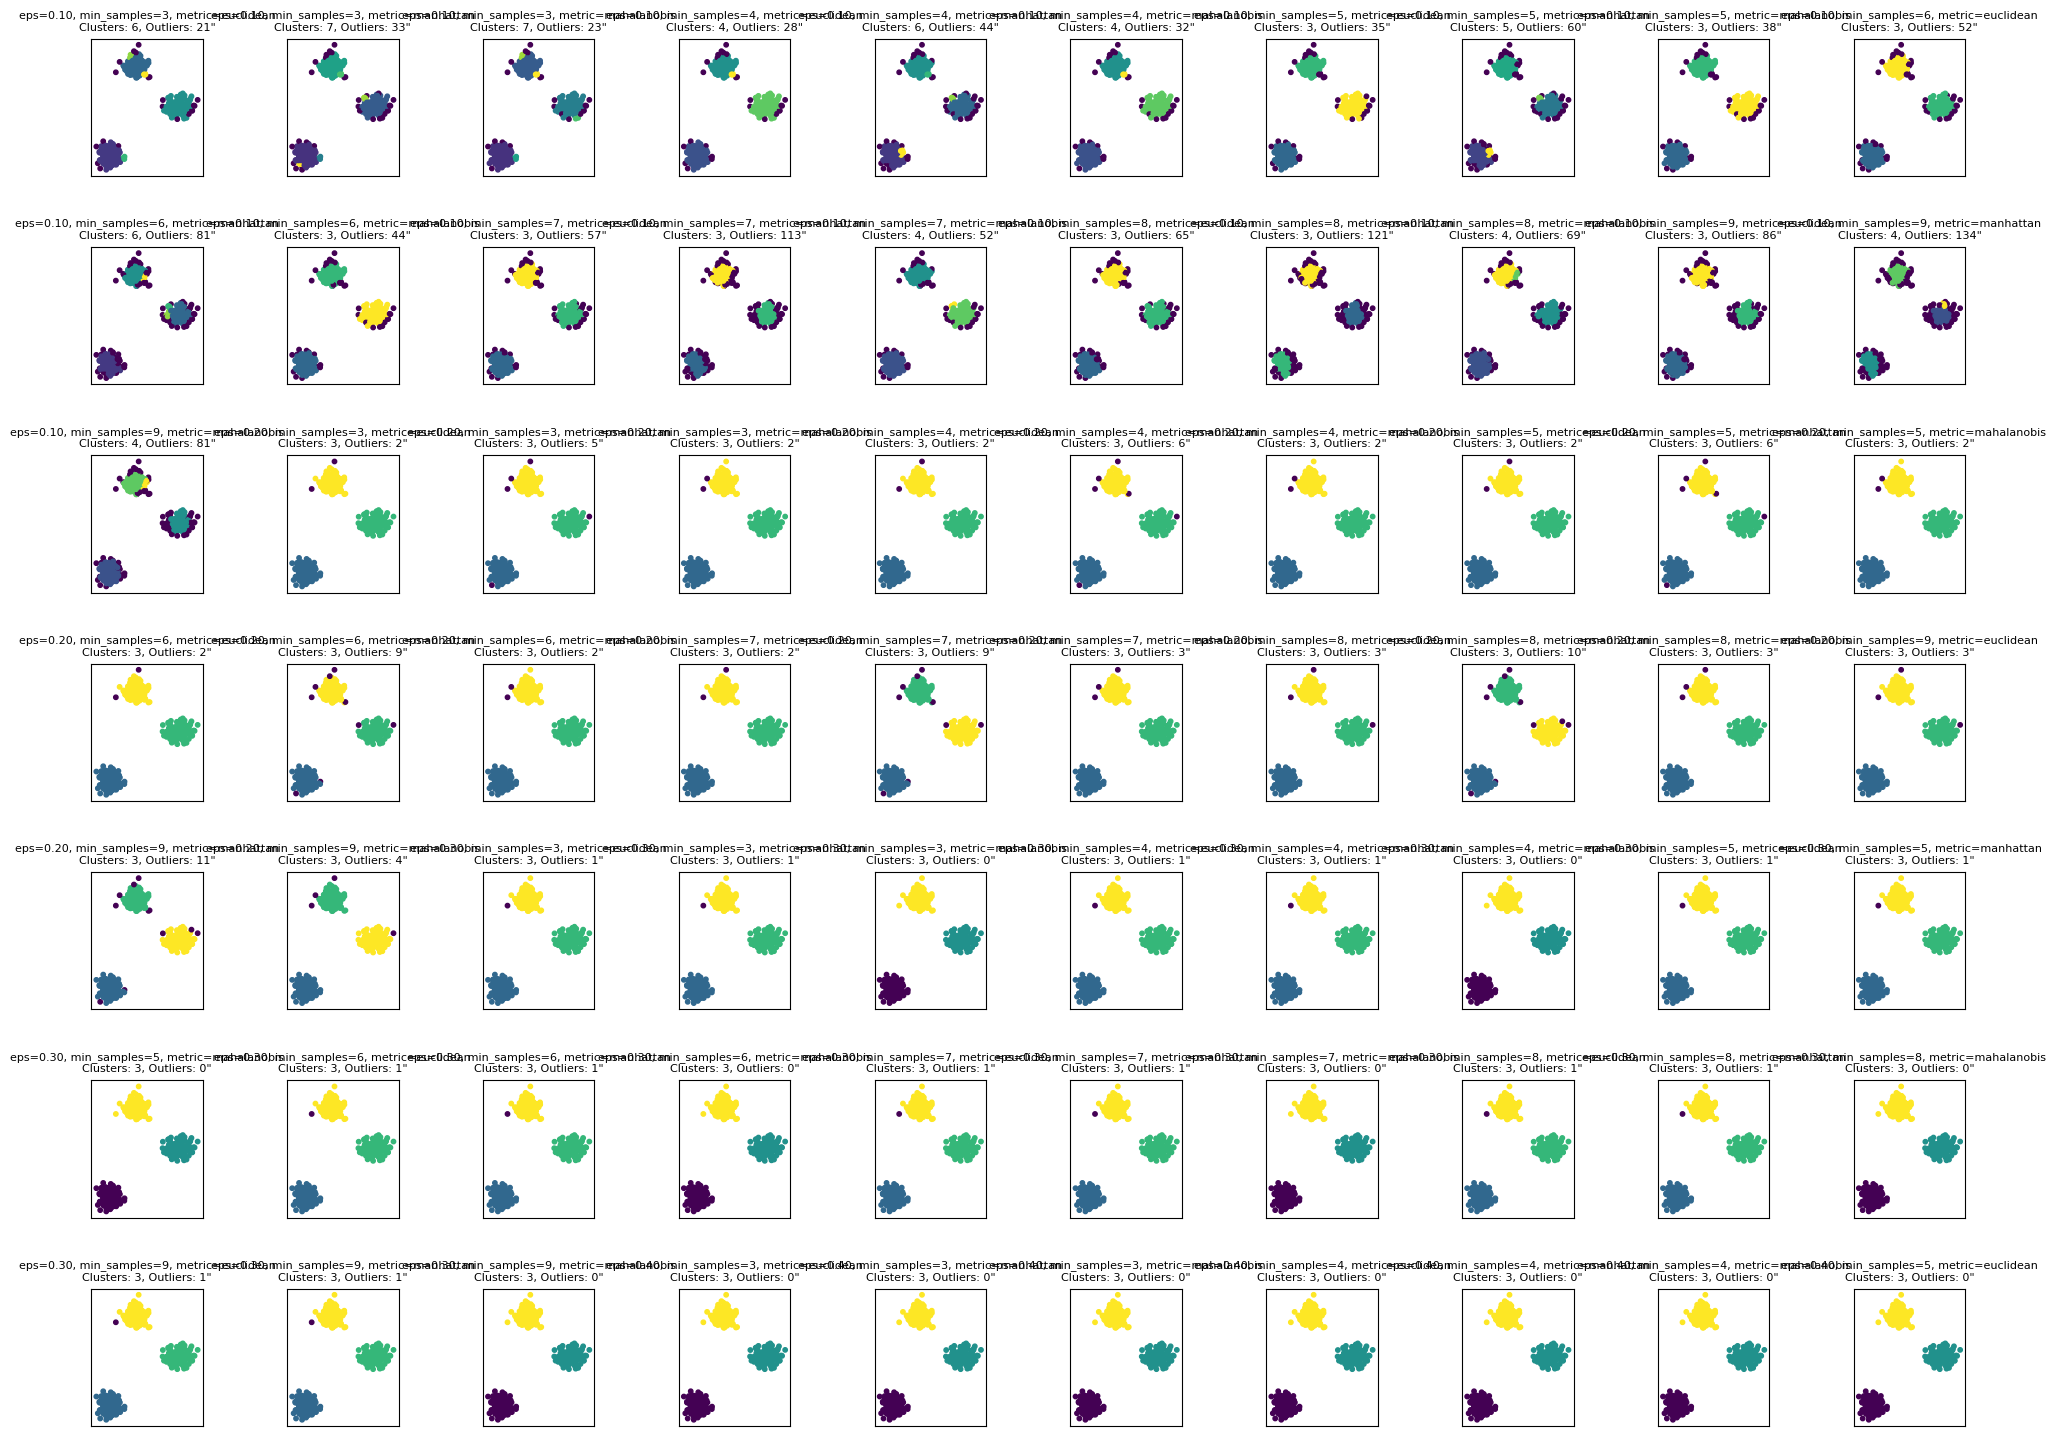

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles, make_classification, make_gaussian_quantiles
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
from sklearn.covariance import EmpiricalCovariance
import itertools

# Custom metric for Mahalanobis
def mahalanobis_distance(X):
    cov = EmpiricalCovariance().fit(X)
    inv_cov = cov.precision_
    return lambda u, v: mahalanobis(u, v, inv_cov)

# Dataset options
dataset_options = {
    'blobs': lambda: make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42),
    'moons': lambda: make_moons(n_samples=500, noise=0.05, random_state=42),
    'circles': lambda: make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42),
    'classification': lambda: make_classification(n_samples=500, n_features=2, n_informative=2, n_clusters_per_class=1, random_state=42),
    'gaussian_quantiles': lambda: make_gaussian_quantiles(n_samples=500, n_features=2, random_state=42)
}

# Choose dataset
dataset_name = 'blobs'  # Change this to use a different dataset: 'moons', 'circles', 'classification', 'gaussian_quantiles'
data, labels_true = dataset_options[dataset_name]()

# Standardize dataset
data = StandardScaler().fit_transform(data)

# Hyperparameter grid
eps_values = np.linspace(0.1, 1.0, 10)
min_samples_values = range(3, 10)
metrics = ['euclidean', 'manhattan', mahalanobis_distance(data)]  # Adding Mahalanobis

# Results storage
results = []

# Perform grid search
for eps, min_samples, metric in itertools.product(eps_values, min_samples_values, metrics):
    if callable(metric):  # For Mahalanobis, pass custom function
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    else:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
        
    labels = dbscan.fit_predict(data)
    # Calculate the number of clusters and outliers
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0
                                     )  # Exclude outliers from cluster count
    n_outliers = list(labels).count(-1)
    
    if len(set(labels)) > 1:  # Avoid silhouette score for single cluster
        silhouette = silhouette_score(data, labels)
    else:
        silhouette = -1
        
    results.append({
        'num_clusters':n_clusters,
        'num_outliers': n_outliers,
        'eps': eps,
        'min_samples': min_samples,
        'metric': metric if isinstance(metric, str) else 'mahalanobis',
        'silhouette_score': silhouette
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Plotting
fig, axes = plt.subplots(len(min_samples_values), len(eps_values), figsize=(20, 15))
fig.tight_layout(pad=3.0)

for (eps, min_samples, metric), ax in zip(itertools.product(eps_values, min_samples_values, metrics), axes.flat):
    if callable(metric):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    else:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    
    labels = dbscan.fit_predict(data)
    
    # Calculate the number of clusters and outliers
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0
                                     )  # Exclude outliers from cluster count
    n_outliers = list(labels).count(-1)

    
    
    ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', s=10)
    ax.set_title(
        f'eps={eps:.2f}, min_samples={min_samples}, metric={"mahalanobis" if callable(metric) else metric}\nClusters: {n_clusters}, Outliers: {n_outliers}"',
        fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
plt.savefig('clusters.pdf', dpi=600)

plt.show()

In [14]:
results_df.sort_values('silhouette_score', ascending=False).to_excel('clustering_results.xlsx', index=False)

In [32]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from scipy.spatial import distance
import matplotlib.pyplot as plt

def geometric_median(X, eps=1e-5):
    y = np.mean(X, axis=0)
    while True:
        D = np.linalg.norm(X - y, axis=1)
        nonzeros = (D != 0)
        D_inv = 1 / D[nonzeros]
        W = D_inv / D_inv.sum()
        T = (W[:, np.newaxis] * X[nonzeros]).sum(axis=0)
        num_zeros = len(X) - np.sum(nonzeros)
        if num_zeros == 0:
            y1 = T
        elif num_zeros == len(X):
            return y
        else:
            R = (T - y) * np.sum(D_inv)
            r = np.linalg.norm(R)
            rinv = 0 if r == 0 else num_zeros / r
            y1 = max(0, 1 - rinv) * T + min(1, rinv) * y
        if np.linalg.norm(y - y1) < eps:
            return y1
        y = y1
def cluster_and_analyze(data, eps, min_samples, metric='euclidean'):
    # Ensure input is a DataFrame, numeric columns only
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)
    
    numeric_data = data.select_dtypes(include=[np.number])
    
    db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    data['cluster'] = db.fit_predict(numeric_data)
    
    # Remove outliers (cluster label -1)
    clustered_data = data[data['cluster'] != -1]
    
    result_frames = []
    
    for cluster_label in clustered_data['cluster'].unique():
        cluster_data = clustered_data[clustered_data['cluster'] == cluster_label].drop(columns=['cluster'])
        median = geometric_median(cluster_data.values)
        
        # Calculate distance from each point in this cluster to the median
        distances = cluster_data.apply(lambda row: distance.euclidean(row.values, median), axis=1)
        temp_df = pd.DataFrame({'cluster': cluster_label, 'distance': distances})
        
        result_frames.append(temp_df)
    
    final_df = pd.concat(result_frames).reset_index(drop=True)
    
    return final_df

def plot_density_histograms(df):
    for cluster_label in df['cluster'].unique():
        cluster_distances = df[df['cluster'] == cluster_label]['distance']
        plt.figure()
        plt.hist(cluster_distances, bins=30, density=True, alpha=0.6)
        plt.title(f'Cluster {cluster_label} - Distance Density Histogram')
        plt.xlabel('Distance')
        plt.ylabel('Density')
        plt.grid(True)
        plt.show()

# Example usage:
# data = pd.DataFrame(...)  # Your dataset
# eps = 0.5
# min_samples = 5
# metric = 'euclidean'
# final_df = cluster_and_analyze(data, eps, min_samples, metric)
# plot_density_histograms(final_df)

In [33]:
dataset_options = {
    'blobs': lambda: make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42),
    'moons': lambda: make_moons(n_samples=500, noise=0.05, random_state=42),
    'circles': lambda: make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42),
    'classification': lambda: make_classification(n_samples=500, n_features=2, n_informative=2, n_clusters_per_class=1, random_state=42),
    'gaussian_quantiles': lambda: make_gaussian_quantiles(n_samples=500, n_features=2, random_state=42)
}

# Choose dataset
dataset_name = 'blobs'  # Change this to use a different dataset: 'moons', 'circles', 'classification', 'gaussian_quantiles'
data, labels_true = dataset_options[dataset_name]()

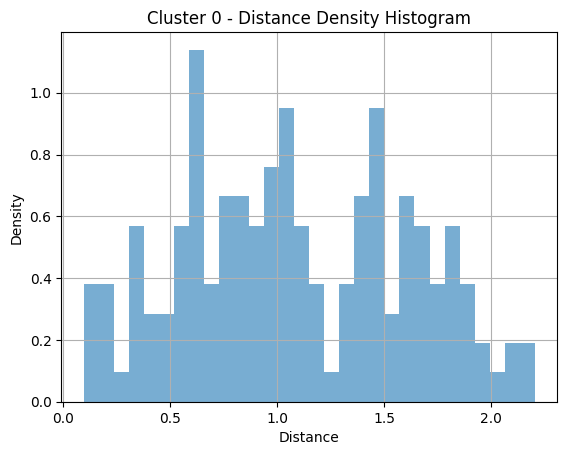

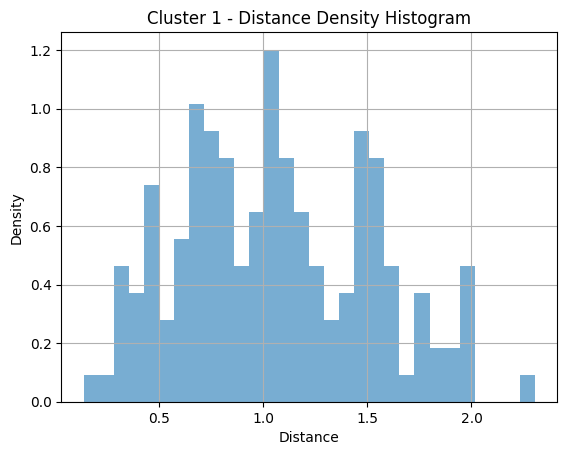

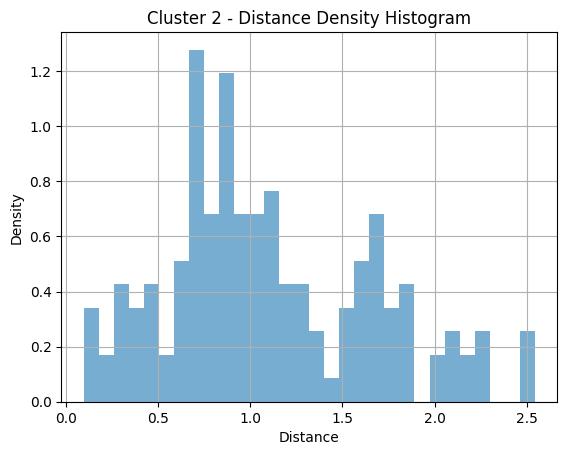

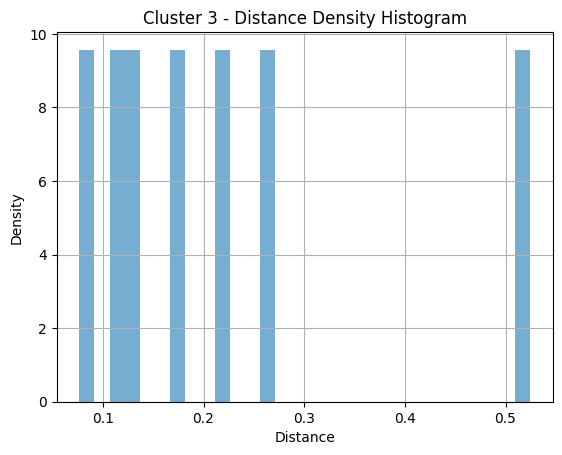

In [34]:
data = pd.DataFrame(data)
eps = 0.5
min_samples = 5
metric = 'euclidean'
final_df = cluster_and_analyze(data, eps, min_samples, metric)
plot_density_histograms(final_df)

In [29]:
data

,0,1,cluster
0,-0.864586,-1.378938,0
1,0.728634,0.076453,1
2,1.743260,-0.039033,1
3,-0.277189,0.939058,2
4,1.537999,0.022266,1
...,...,...,...
495,-0.812661,-1.129616,0
496,-0.211784,1.215468,2
497,1.218871,0.340403,1
498,-1.211743,-1.110566,0
